# Нелинейные уравнения мелкой воды (1D)

Решается полная нелинейная система уравнений мелкой воды в одномерной постановке с помощью схемы Лакса–Вендрофа для распада разрыва.

Система уравнений в консервативной форме:
$$
\partial_t h + \partial_x(hu) = 0, \quad
\partial_t(hu) + \partial_x\left(hu^2 + \tfrac12 g h^2\right) = 0.
$$

Вектор консервативных переменных и поток:
$$
q = \begin{pmatrix} h \\ m \end{pmatrix}, \quad m = hu, \quad
F(q) = \begin{pmatrix} m \\ \dfrac{m^2}{h} + \tfrac12 g h^2 \end{pmatrix}.
$$

Начальные условия:
$$
h(x,0) = \begin{cases}
h_L, & x < 0{.}5,\\
h_R, & x > 0{.}5,
\end{cases}
\quad u(x,0) = 0, \quad h_L > h_R.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
g = 9.81       
L = 1.0        
Nx = 1000      
dx = L / Nx    

# Высоты воды слева и справа от разрыва в начальный момент
h_L = 1.0      # слева
h_R = 0.2      # справа

CFL = 0.9      
T_end = 0.20  

h_min = 1e-8   

In [3]:
# Инициализация сетки и начальных условий
x = np.linspace(0.0, L, Nx, endpoint=False) + 0.5*dx  

# Массив консервативных переменных q = [h, m], где m = h*u
q = np.zeros((2, Nx))

# Инициализируем глубину h(x,0)
q[0, x < 0.5] = h_L
q[0, x >= 0.5] = h_R

# Начальная скорость u(x,0) = 0 => импульс m = 0
q[1, :] = 0.0

def cons_to_prim(q):
    """Преобразование консервативных переменных q = [h, m]
    к глубина h и скорость u.
    """
    h = q[0].copy()
    m = q[1].copy()

    # Защита от деления на ноль: используем безопасную глубину
    h_safe = np.maximum(h, h_min)
    u = m / h_safe

    # В почти сухих зонах принудительно обнулим скорость
    u = np.where(h > h_min, u, 0.0)
    return h, u

def flux(q):
    """Вычисление потока F(q) для уравнений мелкой воды.
    На вход подается массив консервативных переменных q.
    """
    h, u = cons_to_prim(q)
    m = q[1]

    F1 = m                        # поток для уравнения массы
    F2 = m * u + 0.5 * g * h * h  # поток для уравнения импульса

    return np.vstack((F1, F2))

def max_wavespeed(q):
    """Расчет максимальной скорости распространения сигналов |u| + c,
    где c = sqrt(g*h) — гравитационная волновая скорость.
    Используется для подбора шага по времени из условия CFL.
    """
    h, u = cons_to_prim(q)
    c = np.sqrt(g * np.maximum(h, 0.0))
    return np.max(np.abs(u) + c)

def apply_outflow_bc(q):
    """Простые вытекающие (неотражающие) граничные условия.
    Приближаются нулевой производной по x: копируем соседние значения
    во внешние (фиктивные) ячейки.
    """
    q[:, 0]  = q[:, 1]
    q[:, -1] = q[:, -2]
    return q


In [4]:
def lax_wendroff_step(q, dt, dx):
    q = apply_outflow_bc(q)

    # Потоки в целых ячейках в момент времени n
    F = flux(q)

    # Шаг 1
    q_ip1_2 = 0.5 * (q[:, 1:] + q[:, :-1]) - 0.5 * (dt / dx) * (F[:, 1:] - F[:, :-1])

    # Потоки на полуинтервалах при t + dt/2
    F_half = flux(q_ip1_2)

    # Шаг 2
    q_new = q.copy()
    q_new[:, 1:-1] = q[:, 1:-1] - (dt / dx) * (F_half[:, 1:] - F_half[:, :-1])

    # Защита положительности глубины: обрезаем h снизу и обнуляем импульс
    h = q_new[0]
    m = q_new[1]
    neg = h < h_min
    if np.any(neg):
        h[neg] = h_min
        m[neg] = 0.0
    q_new[0] = h
    q_new[1] = m

    return q_new


In [5]:
# Основной цикл по времени с адаптивным шагом dt по критерию CFL
t = 0.0

# Моменты времени, в которые будем сохранять решение для визуализации
snap_times = [0.00, 0.03, 0.06, 0.10, 0.15, T_end]
snapshots_h = {}
snapshots_u = {}

# Сохраняем начальное состояние
h0, u0 = cons_to_prim(q)
snapshots_h[0.0] = h0.copy()
snapshots_u[0.0] = u0.copy()

step = 0

while t < T_end - 1e-14:
    amax = max_wavespeed(q)

    dt = CFL * dx / (amax + 1e-14)

    if t + dt > T_end:
        dt = T_end - t

    # Шаг по времени
    q = lax_wendroff_step(q, dt, dx)
    t += dt
    step += 1

    # Сохранение срезов решения в указанные моменты времени
    for ts in snap_times:
        if ts not in snapshots_h and abs(t - ts) <= 0.5 * dt:
            h_s, u_s = cons_to_prim(q)
            snapshots_h[ts] = h_s.copy()
            snapshots_u[ts] = u_s.copy()

print(f"Итоговое время: t = {t:.6f} с, число шагов: {step}")


Итоговое время: t = 0.200000 с, число шагов: 969


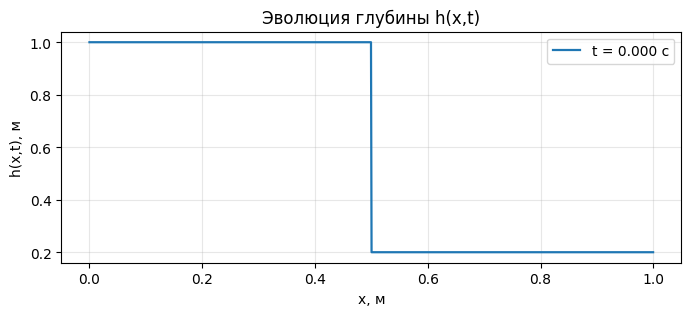

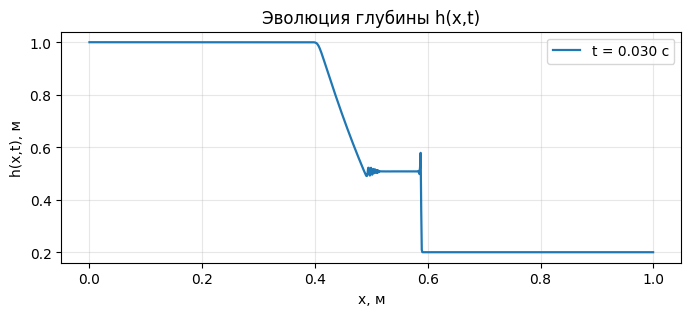

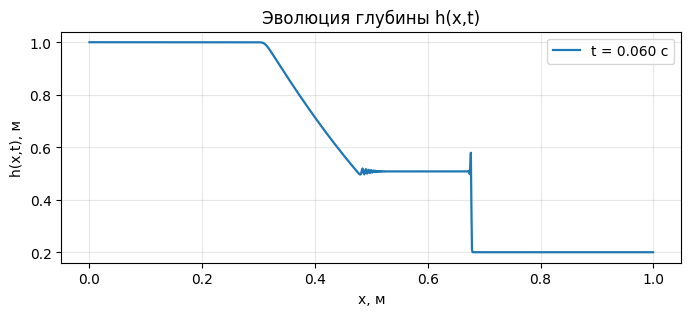

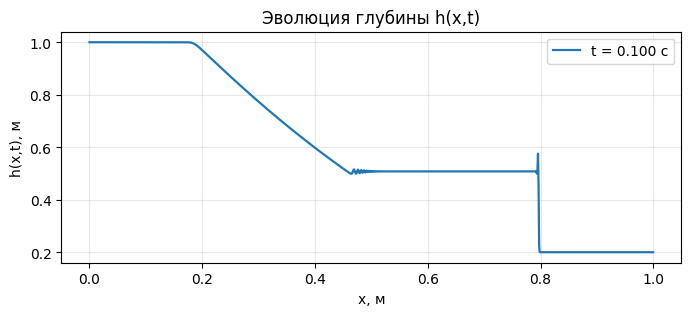

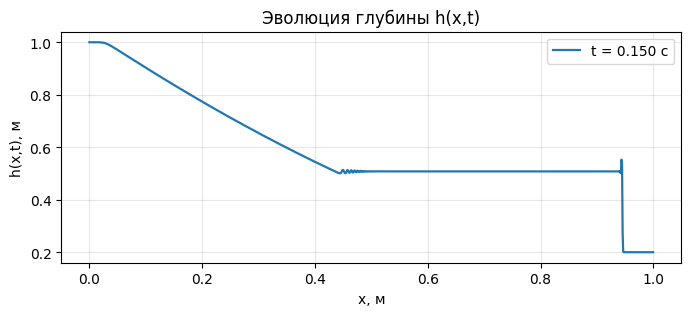

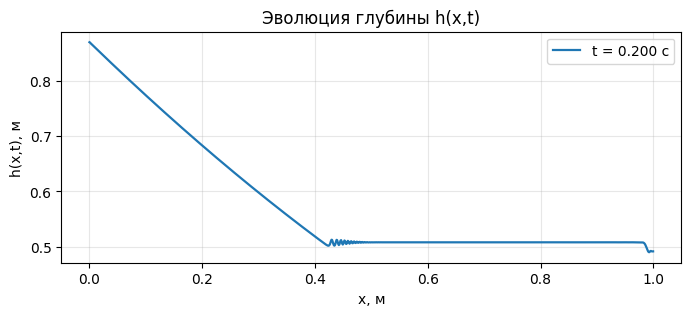

In [6]:
# Визуализация эволюции глубины h(x,t) в разные моменты времени
for ts in sorted(snapshots_h.keys()):
    plt.figure(figsize=(8, 3))
    plt.plot(x, snapshots_h[ts], lw=1.6, label=f"t = {ts:.3f} с")
    plt.xlabel('x, м')
    plt.ylabel('h(x,t), м')
    plt.title('Эволюция глубины h(x,t)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


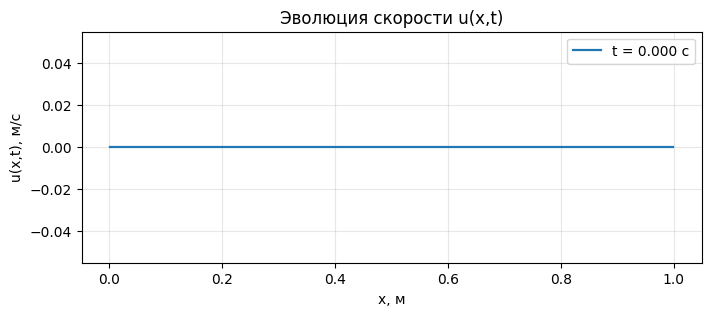

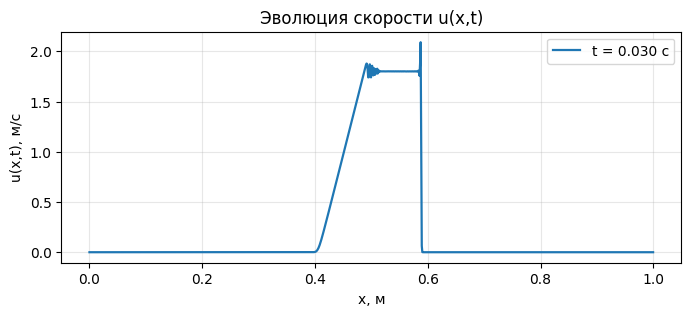

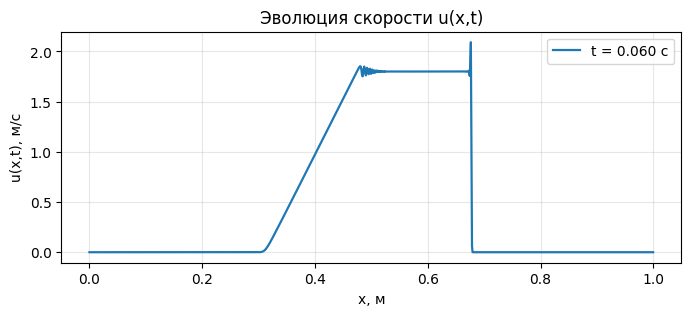

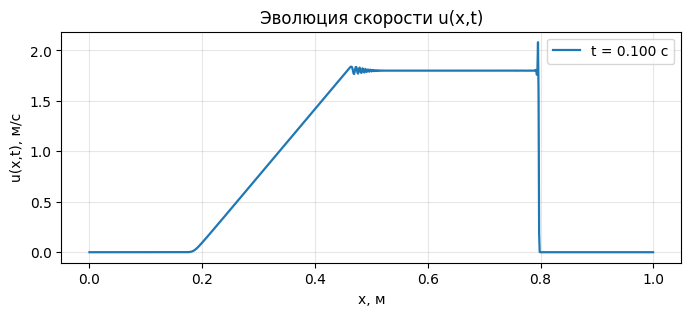

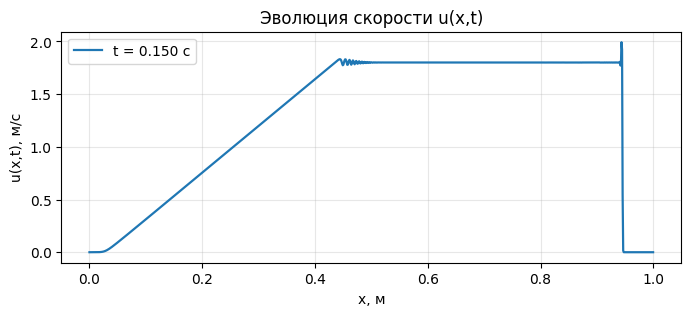

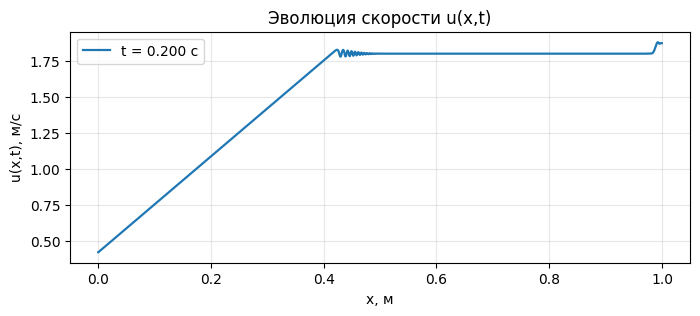

In [7]:
# Визуализация эволюции скорости u(x,t)
for ts in sorted(snapshots_u.keys()):
    plt.figure(figsize=(8, 3))
    plt.plot(x, snapshots_u[ts], lw=1.6, label=f"t = {ts:.3f} с")
    plt.xlabel('x, м')
    plt.ylabel('u(x,t), м/с')
    plt.title('Эволюция скорости u(x,t)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
